**Import Labrarirs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


**Upload the Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


**Load the Dataset**

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Check dataset information**

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

**Check missing values**

In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total Missing Values: 0


**Check duplicates**

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


**Check data Types**

In [8]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


**Convert Data Columns**

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


**Clean Text Clumns**

In [10]:
text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


**Check Invalid Numerical Values**

In [11]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Zero or Negative Quantity:", (df['Quantity'] <= 0).sum())
print("Invalid Discounts:", ((df['Discount'] < 0) | (df['Discount'] > 1)).sum())

Negative Sales: 0
Zero or Negative Quantity: 0
Invalid Discounts: 0


**Check Outliers**

In [12]:
for column in ['Sales', 'Profit']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column, "Outliers:", len(outliers))

Sales Outliers: 1167
Profit Outliers: 1881


**Visualize the Ouliers**

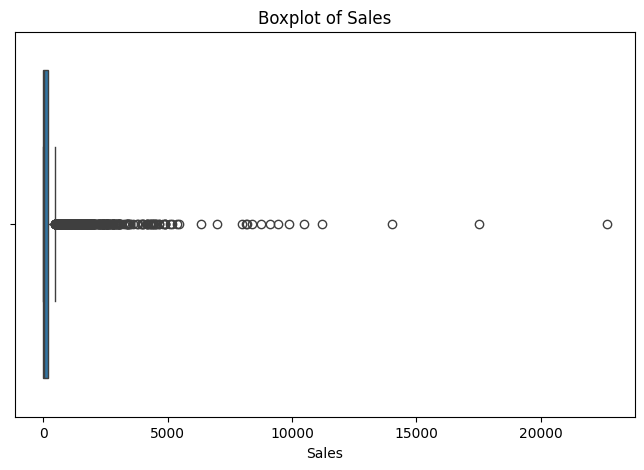

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Sales'])
plt.title('Boxplot of Sales')
plt.xlabel('Sales')
plt.show()

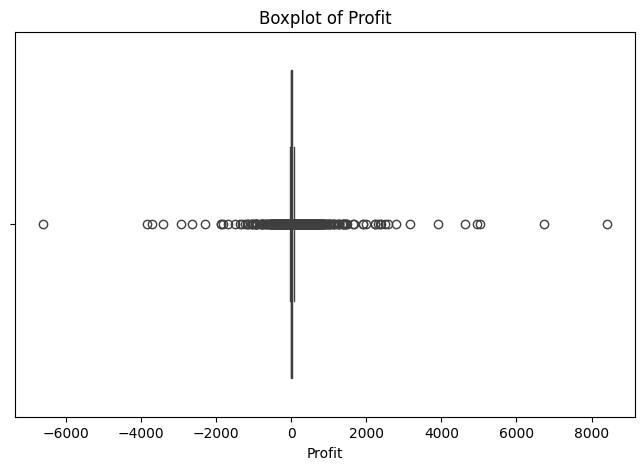

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Profit'])
plt.title('Boxplot of Profit')
plt.xlabel('Profit')
plt.show()

**Check Shipping Dates**

In [15]:
invalid_shipping = df[df['Ship Date'] < df['Order Date']]

print("Orders with Ship Date before Order Date:", len(invalid_shipping))

Orders with Ship Date before Order Date: 0


**Final data Quality Check**

In [16]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (9994, 21)
Missing Values: 0
Duplicate Rows: 0


**Save the Cleaned Dataset**

In [17]:
df.to_csv('Cleaned_Superstore.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


**Download the Cleaned Dataset**

In [18]:
from google.colab import files

files.download('Cleaned_Superstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Data Cleaning Summary***



The dataset was systematically checked and cleaned before further analysis.

- Missing values were checked across all columns.
- Duplicate records were identified and checked.
- Order Date and Ship Date were converted to appropriate datetime format.
- Text columns were cleaned by removing unnecessary spaces.
- Sales, Quantity, and Discount columns were checked for invalid values.
- Sales and Profit were examined for potential outliers using the IQR method.
- Negative profit values were retained because they represent genuine business losses.
- Outliers were not automatically removed because unusually large transactions may represent valid customer purchases.
- Shipping dates were checked to ensure that Ship Date did not occur before Order Date.
- A final data quality check was performed after cleaning.

***Conclusion***



The Sample Superstore dataset was successfully cleaned and prepared for further analysis. The dataset was checked for missing values, duplicate records, incorrect data types, invalid numerical values, and inconsistent date information. The date columns were converted into the correct format, and unnecessary spaces were removed from text data. Sales and profit outliers were also examined, but valid extreme transactions were retained to avoid losing important business information. Negative profit values were kept because they represent genuine business losses. Overall, the data cleaning process improved the consistency, accuracy, and reliability of the dataset, making it suitable for further data analysis and visualization.
